# 02 · Stability sweep

Hold every input fixed **except the Obukhov length `L`** and watch the footprint
respond to atmospheric stability, from convective (`L < 0`) through neutral
(`|L| → ∞`) to stable (`L > 0`). We render a small-multiples panel and tabulate
`x_peak` for each case.

In [1]:
%matplotlib inline
import warnings

import matplotlib.pyplot as plt
import numpy as np

import lagranged as lg

warnings.filterwarnings("ignore", message="No measured TowerTurbulence")

# Fixed everything-but-L base state.
BASE = dict(zm=3.0, z0=0.03, d=0.2, ustar=0.35, umean=2.4, wind_dir=210.0,
            h=1000.0, sigma_v=0.6)
GRID = lg.DomainGrid(nx=80, ny=80, dx=3.0, dy=3.0, x0=-90.0, y0=-120.0)
FAST = dict(n_particles=600, dt_factor=0.05, t_max=120.0, rebound_height=0.5)

# Ordered from convective to stable (by the stability parameter zm/L).
CASES = [
    ("very unstable", -20.0),
    ("unstable",      -100.0),
    ("neutral",       -10_000.0),
    ("stable",        200.0),
]

## Run one footprint per stability class

In [2]:
results = {}
for i, (label, L) in enumerate(CASES):
    results[label] = lg.compute_footprint(L=L, grid=GRID, seed=100 + i, **BASE, **FAST)

for (label, L), r in zip(CASES, results.values(), strict=True):
    zL = BASE["zm"] / L
    print(f"{label:>13}  L={L:>10.1f}  z/L={zL:+.3f}  "
          f"x_peak={r.x_peak:6.1f} m  touchdowns={r.n_touchdowns}")

very unstable  L=     -20.0  z/L=-0.150  x_peak=  22.5 m  touchdowns=202
     unstable  L=    -100.0  z/L=-0.030  x_peak=  22.5 m  touchdowns=250
      neutral  L=  -10000.0  z/L=-0.000  x_peak=  16.5 m  touchdowns=283
       stable  L=     200.0  z/L=+0.015  x_peak=  22.5 m  touchdowns=310


## Small-multiples

Each panel shares the same axes so the change in footprint **extent and shape** is
directly comparable across stability.

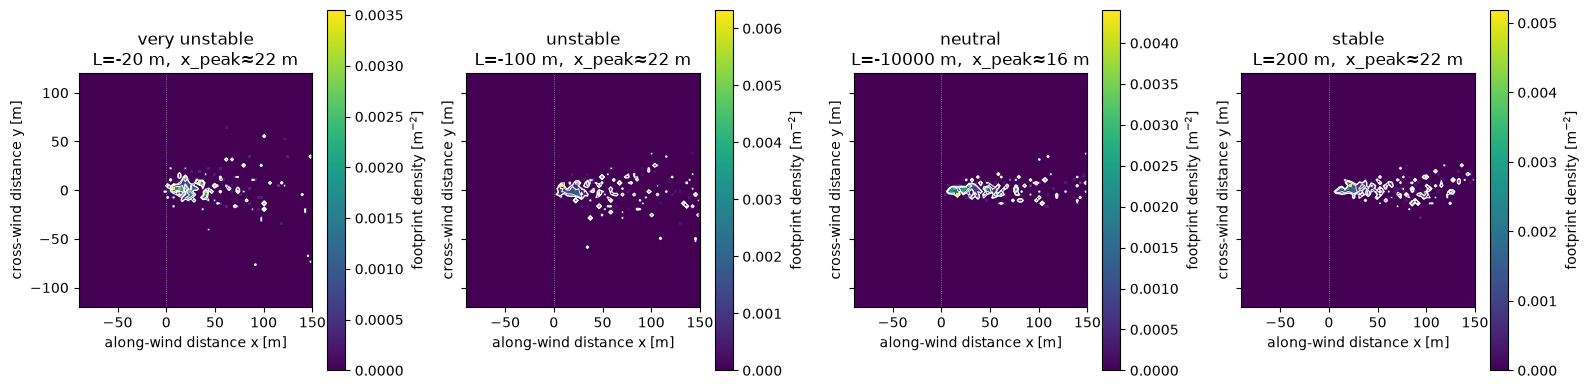

In [3]:
fig, axes = plt.subplots(1, len(CASES), figsize=(16, 4), sharex=True, sharey=True)
for ax, (label, L) in zip(axes, CASES, strict=True):
    r = results[label]
    lg.plot_footprint(r, ax=ax)
    lg.plot_contours(r, ax=ax, colors="white", linewidths=0.7)
    ax.axvline(0.0, color="0.6", lw=0.6, ls=":")
    ax.set_title(f"{label}\nL={L:g} m,  x_peak≈{r.x_peak:.0f} m")
fig.tight_layout()
plt.show()

## Peak distance vs. stability

The crosswind-integrated peak `x_peak` summarizes how far upwind the footprint
reaches. Plotting it against the stability parameter `z/L` shows the trend at a
glance.

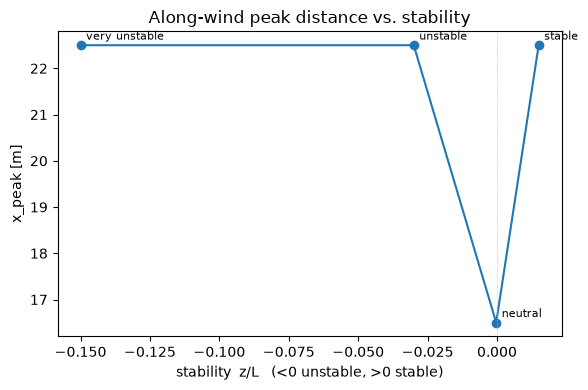

In [4]:
zL = np.array([BASE["zm"] / L for _, L in CASES])
xpk = np.array([results[label].x_peak for label, _ in CASES])
order = np.argsort(zL)

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(zL[order], xpk[order], "o-")
for (label, _), x, y in zip(CASES, zL, xpk, strict=True):
    ax.annotate(label, (x, y), textcoords="offset points", xytext=(4, 4), fontsize=8)
ax.axvline(0.0, color="0.7", lw=0.6, ls=":")
ax.set_xlabel("stability  z/L   (<0 unstable, >0 stable)")
ax.set_ylabel("x_peak [m]")
ax.set_title("Along-wind peak distance vs. stability")
fig.tight_layout()
plt.show()

Stability reshapes both the **reach** and the **peak distance** of the footprint.
The exact ordering depends on how the surface-layer turbulence scales with `z/L`
in this research-grade parameterization, and the small particle counts used here
add Monte-Carlo scatter — increase `n_particles` to sharpen the trend. See
[`docs/limitations.md`](../docs/limitations.md) for the caveats.